<a href="https://colab.research.google.com/github/pakharesamiksha3-ctrl/Bank-Marketing-Analysis/blob/main/MyNetflixProject(SVD).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

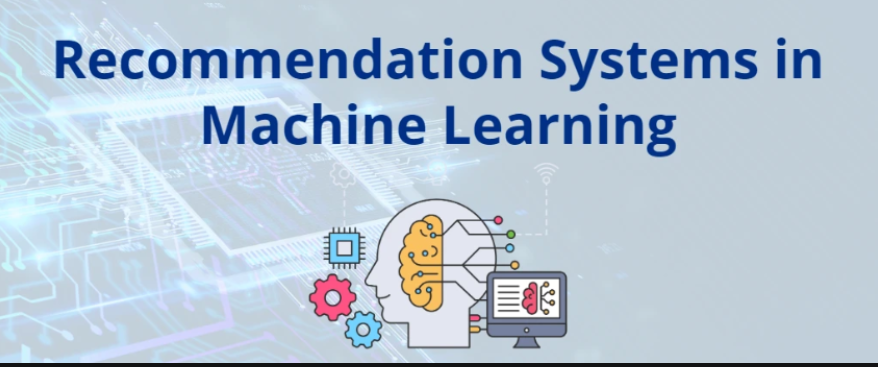

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from google.colab import drive

In [12]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
netflix_dataset = pd.read_csv("/content/drive/MyDrive/Netflix Project/Copy of combinedNetflixData (2).txt", header = None, names=["CustId","Rating"], usecols=[0,1])

In [14]:
netflix_dataset.head(10)

,CustId,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
5,823519,3.0
6,893988,3.0
7,124105,4.0
8,1248029,3.0
9,1842128,4.0


In [15]:
netflix_dataset.tail(20)

,CustId,Rating
24058243,1061120,3.0
24058244,1852040,1.0
24058245,268846,4.0
24058246,2368103,2.0
24058247,529787,4.0
24058248,441248,4.0
24058249,2092745,5.0
24058250,555962,5.0
24058251,303969,2.0
24058252,654591,3.0


In [16]:
netflix_dataset.shape

(24058263, 2)

EDA - Null values, Duplicates

In [17]:
netflix_dataset.isnull().sum()

,0
CustId,0
Rating,4499


# Total Number Of Movies

In [18]:
# number of movies = null values inside rating column

movie_count = netflix_dataset.isnull().sum()["Rating"]

movie_count

4499

# Total Customer Count

In [19]:
total_count = netflix_dataset["CustId"].nunique() # why nunique - posibility of thera will be a multiple users with multiple movies
total_count

475257

In [20]:
customer_count = total_count - movie_count

customer_count

470758

# Total Reviews

In [21]:
rating_count = netflix_dataset['CustId'].count() - movie_count

rating_count

24053764

# Seperate movie if from Customer Id

In [22]:
movie_id = None # movie id is a variable which will iterate through all the movie ids.
movie_id_per_row = []

for i in netflix_dataset['CustId']:
  if ":" in i:
    movie_id = int(i.replace(":","")) # store the value of movie id without colon
  movie_id_per_row.append(movie_id)

In [23]:
movie_id_per_row

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [24]:
netflix_dataset["Movie_ID"] = movie_id_per_row

In [25]:
netflix_dataset.head(10) # here we can see every cust ID have a Movie ID

,CustId,Rating,Movie_ID
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
6,893988,3.0,1
7,124105,4.0,1
8,1248029,3.0,1
9,1842128,4.0,1


In [26]:
netflix_dataset.dropna(inplace = True) # To delete all null values

In [27]:
netflix_dataset.isnull().sum() #To check if there is have any null values after deleting

,0
CustId,0
Rating,0
Movie_ID,0


In [28]:
netflix_dataset.head(10) # Now the dataset looks clean

,CustId,Rating,Movie_ID
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
6,893988,3.0,1
7,124105,4.0,1
8,1248029,3.0,1
9,1842128,4.0,1
10,2238063,3.0,1


In [29]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   CustId    object 
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [30]:
# Covert CustId to in digit(int) because its in object data type

netflix_dataset["CustId"] = netflix_dataset["CustId"].astype(int)


In [31]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   CustId    int64  
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [32]:
netflix_dataset.head(10)

,CustId,Rating,Movie_ID
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
6,893988,3.0,1
7,124105,4.0,1
8,1248029,3.0,1
9,1842128,4.0,1
10,2238063,3.0,1


# Create a list of moview with very few ratings (to remove it)

In [33]:
# find out for every movie id how many ratings do you have

In [34]:
summary = netflix_dataset.groupby("Movie_ID")["Rating"].agg(["count"]) # when we use aggrigatte this count becomes a column name

In [35]:
summary

,count
Movie_ID,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [36]:
# Now we will keep a benchmark at 60th percentile

movie_benckmark = round(np.percentile(summary["count"],60, method = "linear"))

movie_benckmark # so we will find that 60% data lies in 908

908

In [37]:
drop_movie_list = summary[summary["count"]<movie_benckmark].index #we will get the movies whih have to remove

drop_movie_list

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_ID', length=2699)

In [38]:
# For Cust ID

summary_cust = netflix_dataset.groupby("CustId")["Rating"].agg(["count"])

summary_cust

,count
CustId,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [39]:
CustId_benchmark = round(np.percentile(summary_cust["count"],60, method = "linear"))

CustId_benchmark

36

In [40]:
drop_CustId_list = summary_cust[summary_cust["count"]<CustId_benchmark].index

drop_CustId_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='CustId', length=282042)

In [41]:
netflix_dataset = netflix_dataset[~netflix_dataset["Movie_ID"].isin(drop_movie_list)]

# So it checks all the movies that are present in the drop movie list using membership operator
# then using negotiation sign (~) we filter out all those rows
# finally your data has all the rows with the movie ids not present in the drop movie list

In [42]:
netflix_dataset = netflix_dataset[~netflix_dataset["CustId"].isin(drop_CustId_list)]


In [43]:
netflix_dataset.shape

(19695836, 3)

In [44]:
df_title = pd.read_csv("/content/drive/MyDrive/Netflix Project/Copy of movies (1) (1).csv", encoding = "ISO-8859-1", usecols=[0,1,2])

 # Uses the Latin-1 encoding, which is useful if the file contains special characters that cause a UTF-8 decoding error.

In [45]:
df_title.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB


In [46]:
# Rename movieId to Movie_ID in df_title

df_title.rename(columns={'movieId': 'Movie_ID'}, inplace=True)

In [47]:
# lets start model building

!pip install numpy==1.26.4

In [48]:
!pip install scikit-surprise

# It is widely used in projects like Netflix, MovieLens, Amazon product recommendations, and other personalized recommendation systems.

* The Reader class tells surprise how to interpret your ratings data, especially
the rating scale.
* Dataset converts your pandas DataFrame into a format that surprise can use for training.
* SVD stands for Singular Value Decomposition. It is one of the most popular collaborative filtering algorithms for recommendation systems. It learns hidden (latent) factors that represent users and items. For example, it might learn that:


    * User A prefers action movies.

    * User B prefers comedies.

    * Movie X is mostly an action movie.

Using these learned factors, it predicts how a user would rate a movie they haven't seen.

# Reader defines the format and rating scale of your data.

# Dataset converts your DataFrame into a format that surprise can train on.

# SVD is the recommendation algorithm that predicts users' ratings for items they haven't rated yet.

In [49]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [50]:
reader = Reader() #creating an object of reader

In [51]:
data = Dataset.load_from_df(netflix_dataset[["CustId", "Movie_ID", "Rating"]][:100000], reader) # using this [:100000] because i have way to much of data inside my dataset

In [52]:
data # so this data converted into SVD becuase of that we cannot see this in tabular formate

In [53]:
# after the data is ready we will create a module

model = SVD()

In [54]:
cross_validate(model, data, measures = ["RMSE"], cv = 3, verbose = True)

Evaluating RMSE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    1.0194  1.0204  1.0186  1.0195  0.0007  
Fit time          1.61    4.09    4.31    3.34    1.23    
Test time         0.36    0.60    0.53    0.50    0.10    


{'test_rmse': array([1.01942642, 1.02038443, 1.01861244]),
 'fit_time': (1.606325387954712, 4.094156980514526, 4.310744762420654),
 'test_time': (0.3561110496520996, 0.6038491725921631, 0.5324130058288574)}

In [55]:
netflix_dataset["CustId"]

,CustId
696,712664
697,1331154
698,2632461
699,44937
700,656399
...,...
24056842,1055714
24056843,2643029
24056844,267802
24056845,1559566


In [58]:
user_rating = netflix_dataset[netflix_dataset["CustId"] == 1331154]

In [59]:
user_rating

,CustId,Rating,Movie_ID
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [60]:
user_1331154 = df_title.copy()

In [61]:
user_1331154

,Movie_ID,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [62]:
# Remove the less rated movies

user_1331154 = user_1331154[~user_1331154["Movie_ID"].isin(drop_movie_list)]

In [63]:
user_1331154

,Movie_ID,title,genres
2,3,Grumpier Old Men (1995),Comedy|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
7,8,Tom and Huck (1995),Adventure|Children
15,16,Casino (1995),Crime|Drama
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [65]:
user_1331154["Estimated_Score"] = user_1331154['Movie_ID'].apply(lambda x:model.predict(1331154,x).est)

/tmp/ipykernel_8770/1394077155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154["Estimated_Score"] = user_1331154['Movie_ID'].apply(lambda x:model.predict(1331154,x).est)


In [66]:
user_1331154.sort_values("Estimated_Score", ascending = False, inplace = True)

/tmp/ipykernel_8770/2840260142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154.sort_values("Estimated_Score", ascending = False, inplace = True)


In [67]:
user_1331154.head()

,Movie_ID,title,genres,Estimated_Score
24,25,Leaving Las Vegas (1995),Drama|Romance,4.057921
29,30,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama,4.017892
27,28,Persuasion (1995),Drama|Romance,3.754938
14958,75335,Never Forever (2007),Drama|Romance,3.673079
19062,94833,"Pirates! Band of Misfits, The (2012)",Adventure|Animation|Children|Comedy,3.673079
